## Hermes Bottleneck Flow: SFM Calibration Notebook

This notebook uses the Pedestrian Dynamics Data Archive dataset **Pedestrian flow through a bottleneck** to extract Social Force Model (SFM) calibration metrics.

**Reference**

Sieben, A., Schumann, J., & Seyfried, A. (2017). Collective phenomena in crowds—where pedestrian dynamics need social psychology. PLOS ONE, 12(6).

Dataset page: https://ped.fz-juelich.de/da/doku.php?id=hermes_bottleneck  

DOI: https://doi.org/10.34735/ped.2009.6

**About the Dataset**

The dataset is drawn from a study experiment published in 2017. The experiment was conducted in June 2013, at the Exhibition Hall in Dusseldorf and funded by the German Federal Ministry of Education and Research within the programme "Research for Civil Security". Citing the article, *The goal of this experimental setup was to observe a crowd in front of an entrance. This entrance was with guiding barriers where people started queuing in a corridor setup. The instructions given to the participants were: “your favorite artist is playing at the concert and you want to be the first one to enter”.'*

Why this dataset is useful:
- overhead camera view,
- pedestrians only, no vehicles,
- controlled bottleneck geometry,
- bottleneck width is varied across runs,
- trajectories are already provided in cm,
- videos are available for visual verification.

Potential cons:
- Bottleneck width & enclosed area - confined spaces may lead to a reduction in the average walking speed. May not be very transferrable to an open area.
- Experimental study - this is an experimental study and not a real life scenario. Data might be skewed.

This is cleaner than the earlier Shibuya/Reddit footage because we do not need to estimate all trajectories from pixels. The dataset already gives real-world coordinates, so we can go directly to movement metrics for SFM calibration.

### 1. How This Fits The Overall Project

The broader project goal is to calibrate pedestrian movement before using evacuation simulations for larger emergency scenarios.

For Shibuya-style videos, the workflow is:

```text
video pixels -> homography -> tracking -> metre trajectories -> SFM metrics
```

For this Hermes bottleneck dataset, the workflow is simpler:

```text
provided trajectories in cm -> metres -> speed / spacing / flow / density -> SFM calibration
```

This notebook focuses on the second workflow. The videos are still useful, but mainly for checking that the trajectories correspond to realistic overhead pedestrian movement.

Since the dataset authors have already given trajectory coordinates in real world units, we don't need to manually pick 4 points or compute homography to obtain pedestrian speed, spacing, flow or density.

### 2. Setup

This cell imports the libraries, defines local folders, and sets the trajectory frame rate.

The dataset page states that the trajectory/video frame rate is **16 FPS**, so the timestep is:

```text
DT = 1 / 16 seconds
```

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cv2
    OPENCV_AVAILABLE = True
except ImportError:
    OPENCV_AVAILABLE = False
    print("OpenCV is not installed. Video preview cells will not work, but trajectory analysis still works.")

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "hermes_bottleneck"
VIDEO_DIR = DATA_DIR / "videos"
TRAJ_DIR = DATA_DIR / "trajectories"
META_DIR = DATA_DIR / "metadata"
OUTPUT_DIR = DATA_DIR / "outputs"

for folder in [VIDEO_DIR, TRAJ_DIR, META_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

FPS = 16
DT = 1 / FPS

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("FPS:", FPS)

Base directory: c:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM
Data directory: c:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\hermes_bottleneck
FPS: 16


### 3. Check Downloaded Files

This section confirms that the dataset files are in the expected folder structure.

Expected folders:

```text
data/hermes_bottleneck/videos/cam1
data/hermes_bottleneck/videos/cam2
data/hermes_bottleneck/trajectories/txt
data/hermes_bottleneck/metadata
```

In [2]:
files = []
for path in DATA_DIR.rglob("*"):
    if path.is_file():
        files.append({
            "relative_path": str(path.relative_to(DATA_DIR)),
            "size_mb": path.stat().st_size / 1_000_000,
        })

file_inventory = pd.DataFrame(files).sort_values("relative_path")
file_inventory

,relative_path,size_mb
0,metadata\2009bottleneck_metadata.json,0.008288
1,outputs\hermes_bottleneck_calibration_summary.csv,0.001378
2,trajectories\2009bottleneck_trajectories_txt.zip,5.734950
5,trajectories\txt\ao-240-400.txt,4.947074
6,trajectories\txt\ao-300-400.txt,4.229100
7,trajectories\txt\ao-360-400.txt,3.515584
8,trajectories\txt\ao-440-400.txt,3.043384
9,trajectories\txt\ao-500-400.txt,2.602502
3,videos\2009bottleneck_video_cam1.zip,46.263845
4,videos\2009bottleneck_video_cam2.zip,45.830272


### 4. Load Metadata

The metadata describes the experiment, publication DOI, participants, sensors, and run information. We use it mainly for documentation and traceability.

In [3]:
metadata_files = list(META_DIR.rglob("*.json"))
metadata_files

[WindowsPath('c:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/hermes_bottleneck/metadata/2009bottleneck_metadata.json')]

In [4]:
metadata = None
if metadata_files:
    with open(metadata_files[0], "r", encoding="utf-8") as f:
        metadata = json.load(f)

    experiment = metadata.get("experiment", {})
    print("Experiment name:", experiment.get("experiment_name"))
    print("Title:", experiment.get("title"))
    print("About:", experiment.get("about"))
    print("Max participant:", experiment.get("max_participant"))
    print("Publication:", experiment.get("publication"))
else:
    print("No metadata JSON found.")

Experiment name: Hermes_Messe_Bottleneck
Title: Pedestrian flow through a bottleneck
About: The aim of the study was to investigate the influence of the width of a bottleneck on the pedestrian flow.
Max participant: 230
Publication: [{'doi': '10.34735/ped.2009.6'}]


### 5. Inspect Video Files

The videos are useful for visually checking the overhead bottleneck experiment.

The quantitative SFM analysis will mainly use the trajectory files, because they already contain real-world coordinates in centimetres.

In [5]:
video_files = sorted(list((VIDEO_DIR / "cam1").rglob("*.wmv")) + list((VIDEO_DIR / "cam2").rglob("*.wmv")))
video_files[:5], len(video_files)

([WindowsPath('c:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/hermes_bottleneck/videos/cam1/ao-240-400.wmv'),
  WindowsPath('c:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/hermes_bottleneck/videos/cam1/ao-300-400.wmv'),
  WindowsPath('c:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/hermes_bottleneck/videos/cam1/ao-360-400.wmv'),
  WindowsPath('c:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/hermes_bottleneck/videos/cam1/ao-440-400.wmv'),
  WindowsPath('c:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/hermes_bottleneck/videos/cam1/ao-500-400.wmv')],
 10)

In [6]:
def get_video_metadata(video_path):
    if not OPENCV_AVAILABLE:
        return {"path": str(video_path), "opened": False, "reason": "OpenCV unavailable"}

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {"path": str(video_path), "opened": False}

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    duration_s = frame_count / fps if fps else np.nan
    cap.release()

    return {
        "path": str(video_path),
        "file": video_path.name,
        "camera": video_path.parent.name,
        "opened": True,
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height,
        "duration_s": duration_s,
    }

video_meta = pd.DataFrame([get_video_metadata(p) for p in video_files])
video_meta

,path,file,camera,opened,fps,frame_count,width,height,duration_s
0,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-240-400.wmv,cam1,True,16.0,1159.0,640.0,480.0,72.4375
1,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-300-400.wmv,cam1,True,16.0,999.0,640.0,480.0,62.4375
2,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-360-400.wmv,cam1,True,16.0,1095.0,640.0,480.0,68.4375
3,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-440-400.wmv,cam1,True,16.0,775.0,640.0,480.0,48.4375
4,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-500-400.wmv,cam1,True,16.0,1863.0,640.0,480.0,116.4375
5,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-240-400.wmv,cam2,True,16.0,1191.0,640.0,480.0,74.4375
6,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-300-400.wmv,cam2,True,16.0,967.0,640.0,480.0,60.4375
7,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-360-400.wmv,cam2,True,16.0,1047.0,640.0,480.0,65.4375
8,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-440-400.wmv,cam2,True,16.0,743.0,640.0,480.0,46.4375
9,c:\Users\kylet\HTX\Deliverable 1\Documentation...,ao-500-400.wmv,cam2,True,16.0,1912.0,640.0,480.0,119.5000


### 6. Preview One Video Frame

This is a quick visual sanity check. The image should show a top-down bottleneck experiment with participants moving through a narrowed exit.

If this cell fails, it does not block the trajectory analysis. It only affects visual preview.

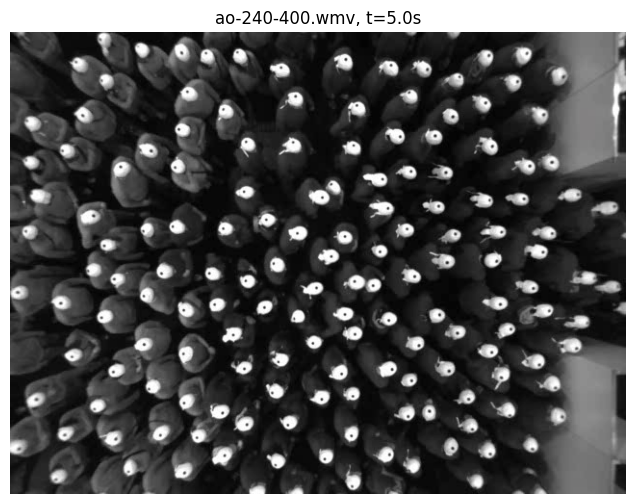

In [7]:
def show_video_frame(video_path, time_s=5.0):
    if not OPENCV_AVAILABLE:
        print("OpenCV unavailable.")
        return

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print("Could not open:", video_path)
        return

    fps = cap.get(cv2.CAP_PROP_FPS) or FPS
    frame_idx = int(time_s * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()

    if not ok:
        print("Could not read frame at", time_s, "seconds")
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.title(f"{Path(video_path).name}, t={time_s:.1f}s")
    plt.axis("off")
    plt.show()

if video_files:
    show_video_frame(video_files[0], time_s=5.0)
else:
    print("No video files found.")

### 7. Load Trajectory Files

Each trajectory file corresponds to one experimental run/bottleneck width.

The text format is:

```text
ID frame x-coordinate [cm] y-coordinate [cm] z-coordinate [cm]
```

We convert centimetres to metres for SFM analysis.

In [8]:
traj_files = sorted((TRAJ_DIR / "txt").rglob("*.txt"))
[(p.name, p.stat().st_size / 1_000_000) for p in traj_files]

[('ao-240-400.txt', 4.947074),
 ('ao-300-400.txt', 4.2291),
 ('ao-360-400.txt', 3.515584),
 ('ao-440-400.txt', 3.043384),
 ('ao-500-400.txt', 2.602502)]

In [9]:
def parse_run_name(path):
    """Extract run name and approximate bottleneck width from file name.

    Example: ao-240-400.txt -> bottleneck_width_cm = 240.
    """
    run_name = Path(path).stem
    match = re.search(r"ao-(\d+)-(\d+)", run_name)
    if match:
        bottleneck_width_cm = int(match.group(1))
        second_value_cm = int(match.group(2))
    else:
        bottleneck_width_cm = np.nan
        second_value_cm = np.nan

    return run_name, bottleneck_width_cm, second_value_cm


def load_trajectory_txt(path):
    run_name, bottleneck_width_cm, second_value_cm = parse_run_name(path)

    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["id", "frame", "x_cm", "y_cm", "z_cm"],
        comment="#",
    )

    df["run"] = run_name
    df["bottleneck_width_cm"] = bottleneck_width_cm
    df["bottleneck_width_m"] = bottleneck_width_cm / 100
    df["x_m"] = df["x_cm"] / 100
    df["y_m"] = df["y_cm"] / 100
    df["z_m"] = df["z_cm"] / 100
    return df

sample_traj = load_trajectory_txt(traj_files[0])
sample_traj.head()

,id,frame,x_cm,y_cm,z_cm,run,bottleneck_width_cm,bottleneck_width_m,x_m,y_m,z_m
0,1,30,-194.198,408.001,163.111,ao-240-400,240,2.4,-1.94198,4.08001,1.63111
1,1,31,-194.198,408.001,163.111,ao-240-400,240,2.4,-1.94198,4.08001,1.63111
2,1,32,-194.274,407.951,163.111,ao-240-400,240,2.4,-1.94274,4.07951,1.63111
3,1,33,-194.139,407.983,163.111,ao-240-400,240,2.4,-1.94139,4.07983,1.63111
4,1,34,-194.189,407.722,163.111,ao-240-400,240,2.4,-1.94189,4.07722,1.63111


### 8. Plot One Run's Trajectories

This helps confirm the coordinate system and overall movement pattern before computing metrics.

For a bottleneck experiment, we expect many trajectories to converge toward the exit/narrowing region.

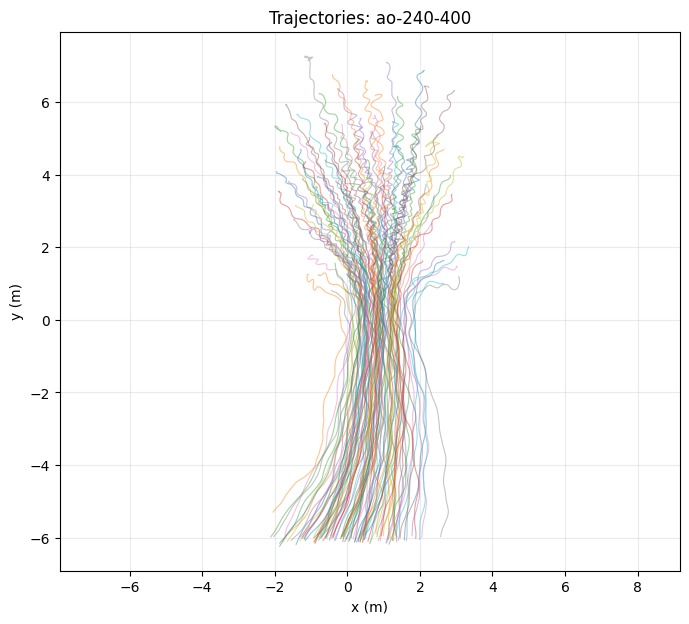

In [10]:
def plot_trajectories(df, max_agents=80, title=None):
    ids = df["id"].drop_duplicates().head(max_agents)
    subset = df[df["id"].isin(ids)]

    plt.figure(figsize=(8, 7))
    for _, g in subset.groupby("id"):
        plt.plot(g["x_m"], g["y_m"], alpha=0.45, linewidth=0.8)

    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(title or f"Trajectories: {df['run'].iloc[0]}")
    plt.axis("equal")
    plt.grid(alpha=0.25)
    plt.show()

plot_trajectories(sample_traj, max_agents=100)

### 9. Compute Speed And Direction

SFM needs realistic movement parameters. The first and most direct metric is walking speed.

For each pedestrian, we compute:

```text
dx = x_t - x_(t-1)
dy = y_t - y_(t-1)
distance = sqrt(dx^2 + dy^2)
speed = distance / dt
```

Direction is computed using `atan2(dy, dx)`.

In [11]:
def add_kinematics(df, fps=FPS):
    out = df.sort_values(["run", "id", "frame"]).copy()
    group_cols = ["run", "id"]

    out["prev_x_m"] = out.groupby(group_cols)["x_m"].shift(1)
    out["prev_y_m"] = out.groupby(group_cols)["y_m"].shift(1)
    out["prev_frame"] = out.groupby(group_cols)["frame"].shift(1)

    out["dt_s"] = (out["frame"] - out["prev_frame"]) / fps
    out.loc[out["dt_s"] <= 0, "dt_s"] = np.nan

    out["dx_m"] = out["x_m"] - out["prev_x_m"]
    out["dy_m"] = out["y_m"] - out["prev_y_m"]
    out["step_distance_m"] = np.sqrt(out["dx_m"] ** 2 + out["dy_m"] ** 2)
    out["speed_mps"] = out["step_distance_m"] / out["dt_s"]
    out["direction_rad"] = np.arctan2(out["dy_m"], out["dx_m"])
    out["direction_deg"] = np.degrees(out["direction_rad"])

    return out

sample_kin = add_kinematics(sample_traj)
sample_kin[["id", "frame", "x_m", "y_m", "speed_mps", "direction_deg"]].head()

,id,frame,x_m,y_m,speed_mps,direction_deg
0,1,30,-1.94198,4.08001,NaN,NaN
1,1,31,-1.94198,4.08001,0.000000,0.000000
2,1,32,-1.94274,4.07951,0.014556,-146.659293
3,1,33,-1.94139,4.07983,0.022199,13.335106
4,1,34,-1.94189,4.07722,0.042519,-100.844811


### 10. Speed Distribution For One Run

This plot gives a first estimate of the desired walking speed distribution for SFM.

We filter out impossible/unrealistic speeds for a clean pilot summary. The filter `0 <= speed <= 4 m/s` is generous enough to include fast movement but exclude tracking artefacts.

count    149904.000000
mean          0.458107
std           0.385662
min           0.000000
25%           0.192265
50%           0.303475
75%           0.602342
max           3.354809
Name: speed_mps, dtype: float64


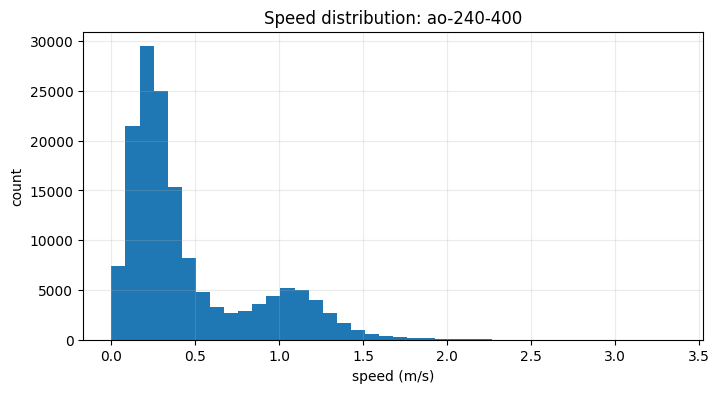

In [12]:
def clean_speed(series, max_speed=4.0):
    speed = series.replace([np.inf, -np.inf], np.nan).dropna()
    return speed[(speed >= 0) & (speed <= max_speed)]

speed_clean = clean_speed(sample_kin["speed_mps"])
print(speed_clean.describe())

plt.figure(figsize=(8, 4))
plt.hist(speed_clean, bins=40)
plt.xlabel("speed (m/s)")
plt.ylabel("count")
plt.title(f"Speed distribution: {sample_traj['run'].iloc[0]}")
plt.grid(alpha=0.25)
plt.show()

### 11. Load All Runs

Now we combine all trajectory text files so that we can compare different bottleneck widths.

This may take a few seconds because the files contain many trajectory rows, but it should still be much faster than running a large SFM simulation.

In [13]:
all_traj = pd.concat([load_trajectory_txt(p) for p in traj_files], ignore_index=True)
all_kin = add_kinematics(all_traj)

print("Rows:", len(all_kin))
print("Runs:", all_kin["run"].nunique())
print("Pedestrians:", all_kin.groupby("run")["id"].nunique().to_dict())
all_kin.head()

Rows: 554420
Runs: 5
Pedestrians: {'ao-240-400': 352, 'ao-300-400': 348, 'ao-360-400': 350, 'ao-440-400': 350, 'ao-500-400': 348}


,id,frame,x_cm,y_cm,z_cm,run,bottleneck_width_cm,bottleneck_width_m,x_m,y_m,...,prev_x_m,prev_y_m,prev_frame,dt_s,dx_m,dy_m,step_distance_m,speed_mps,direction_rad,direction_deg
0,1,30,-194.198,408.001,163.111,ao-240-400,240,2.4,-1.94198,4.08001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,31,-194.198,408.001,163.111,ao-240-400,240,2.4,-1.94198,4.08001,...,-1.94198,4.08001,30.0,0.0625,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000
2,1,32,-194.274,407.951,163.111,ao-240-400,240,2.4,-1.94274,4.07951,...,-1.94198,4.08001,31.0,0.0625,-0.00076,-0.00050,0.000910,0.014556,-2.559688,-146.659293
3,1,33,-194.139,407.983,163.111,ao-240-400,240,2.4,-1.94139,4.07983,...,-1.94274,4.07951,32.0,0.0625,0.00135,0.00032,0.001387,0.022199,0.232742,13.335106
4,1,34,-194.189,407.722,163.111,ao-240-400,240,2.4,-1.94189,4.07722,...,-1.94139,4.07983,33.0,0.0625,-0.00050,-0.00261,0.002657,0.042519,-1.760074,-100.844811


### 12. Summary Metrics By Bottleneck Width

This table provides SFM-relevant summaries for each bottleneck width:

- number of pedestrians,
- number of frames,
- mean/median speed,
- speed spread,
- approximate duration.

These values are useful for setting baseline SFM speed distributions and comparing how congestion changes with bottleneck width.

In [14]:
valid = all_kin.copy()
valid["speed_clean_mps"] = valid["speed_mps"]
valid.loc[~valid["speed_clean_mps"].between(0, 4), "speed_clean_mps"] = np.nan

summary = valid.groupby(["run", "bottleneck_width_m"], as_index=False).agg(
    n_pedestrians=("id", "nunique"),
    n_frames=("frame", "nunique"),
    first_frame=("frame", "min"),
    last_frame=("frame", "max"),
    mean_speed_mps=("speed_clean_mps", "mean"),
    median_speed_mps=("speed_clean_mps", "median"),
    std_speed_mps=("speed_clean_mps", "std"),
    p10_speed_mps=("speed_clean_mps", lambda x: np.nanpercentile(x, 10)),
    p90_speed_mps=("speed_clean_mps", lambda x: np.nanpercentile(x, 90)),
)
summary["duration_s"] = (summary["last_frame"] - summary["first_frame"]) / FPS
summary

,run,bottleneck_width_m,n_pedestrians,n_frames,first_frame,last_frame,mean_speed_mps,median_speed_mps,std_speed_mps,p10_speed_mps,p90_speed_mps,duration_s
0,ao-240-400,2.4,352,1100,29,1128,0.458107,0.303475,0.385662,0.120656,1.108227,68.6875
1,ao-300-400,3.0,348,959,0,958,0.505935,0.356600,0.380541,0.142042,1.094345,59.8750
2,ao-360-400,3.6,350,808,14,821,0.586977,0.443724,0.393729,0.187395,1.171033,50.4375
3,ao-440-400,4.4,350,720,0,719,0.650029,0.549896,0.397155,0.218093,1.180541,44.9375
4,ao-500-400,5.0,348,605,1210,1814,0.741921,0.645050,0.427503,0.284062,1.305527,37.7500


### 13. Compare Speed By Bottleneck Width

This plot checks whether speed changes as the bottleneck width changes.

For SFM, this matters because desired speed may be stable, but realised speed decreases under congestion. The difference between desired speed and realised speed is one of the behaviours SFM should reproduce.

After plot, it can be seen that both the mean & median speed increase with an increase in bottleneck width

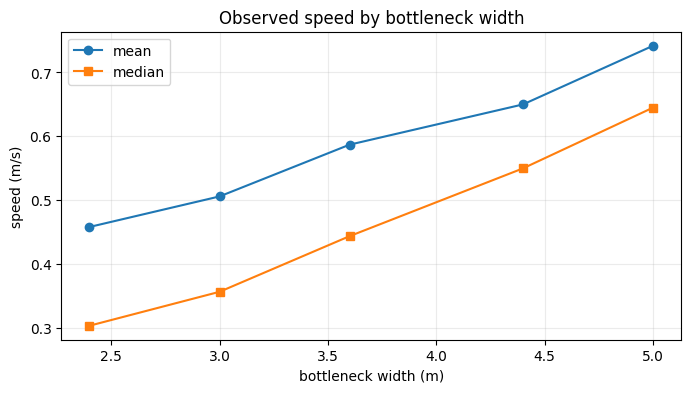

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(summary["bottleneck_width_m"], summary["mean_speed_mps"], marker="o", label="mean")
plt.plot(summary["bottleneck_width_m"], summary["median_speed_mps"], marker="s", label="median")
plt.xlabel("bottleneck width (m)")
plt.ylabel("speed (m/s)")
plt.title("Observed speed by bottleneck width")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### 14. Estimate Nearest-Neighbour Spacing

Social force strength is related to how pedestrians keep distance from each other. A simple observable proxy is nearest-neighbour spacing.

To keep runtime practical, this cell samples frames rather than computing every pairwise distance for every frame.

In [16]:
def nearest_neighbour_spacing(df, frame_step=20, max_frames_per_run=80):
    rows = []

    for run, run_df in df.groupby("run"):
        frames = np.sort(run_df["frame"].unique())[::frame_step][:max_frames_per_run]
        sampled = run_df[run_df["frame"].isin(frames)]

        for frame, g in sampled.groupby("frame"):
            pts = g[["x_m", "y_m"]].to_numpy()
            ids = g["id"].to_numpy()
            if len(pts) < 2:
                continue

            diff = pts[:, None, :] - pts[None, :, :]
            dist = np.sqrt((diff ** 2).sum(axis=2))
            np.fill_diagonal(dist, np.nan)
            nn = np.nanmin(dist, axis=1)

            for ped_id, spacing in zip(ids, nn):
                rows.append({
                    "run": run,
                    "frame": frame,
                    "id": ped_id,
                    "nn_spacing_m": spacing,
                    "bottleneck_width_m": g["bottleneck_width_m"].iloc[0],
                })

    return pd.DataFrame(rows)

spacing = nearest_neighbour_spacing(all_kin, frame_step=20, max_frames_per_run=80)
spacing.head(), spacing.shape

(          run  frame  id  nn_spacing_m  bottleneck_width_m
 0  ao-240-400     29  17      0.564971                 2.4
 1  ao-240-400     29  22      0.549601                 2.4
 2  ao-240-400     29  28      0.394251                 2.4
 3  ao-240-400     29  33      0.401578                 2.4
 4  ao-240-400     29  38      0.397406                 2.4,
 (27952, 5))

,run,bottleneck_width_m,mean_nn_spacing_m,median_nn_spacing_m,p10_nn_spacing_m
0,ao-240-400,2.4,0.428841,0.390236,0.282135
1,ao-300-400,3.0,0.438525,0.403725,0.291127
2,ao-360-400,3.6,0.447063,0.415884,0.302089
3,ao-440-400,4.4,0.458363,0.433077,0.313795
4,ao-500-400,5.0,0.454320,0.429277,0.312720


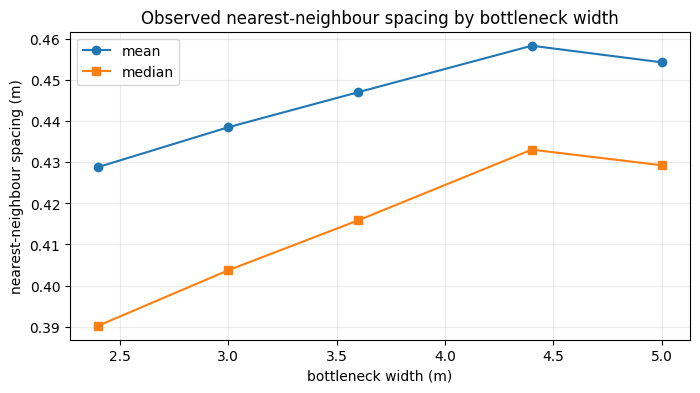

In [17]:
spacing_summary = spacing.groupby(["run", "bottleneck_width_m"], as_index=False).agg(
    mean_nn_spacing_m=("nn_spacing_m", "mean"),
    median_nn_spacing_m=("nn_spacing_m", "median"),
    p10_nn_spacing_m=("nn_spacing_m", lambda x: np.nanpercentile(x, 10)),
)
display(spacing_summary)

spacing_plot = spacing_summary.sort_values("bottleneck_width_m")
plt.figure(figsize=(8, 4))
plt.plot(spacing_plot["bottleneck_width_m"], spacing_plot["mean_nn_spacing_m"], marker="o", label="mean")
plt.plot(spacing_plot["bottleneck_width_m"], spacing_plot["median_nn_spacing_m"], marker="s", label="median")
plt.xlabel("bottleneck width (m)")
plt.ylabel("nearest-neighbour spacing (m)")
plt.title("Observed nearest-neighbour spacing by bottleneck width")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### 15. Estimate Flow Through The Bottleneck

For bottleneck experiments, flow is one of the most important calibration targets.

A simple method is to define a virtual crossing line and count how many unique pedestrians cross it per second.

Because we need to confirm the exact coordinate orientation, this first version uses the median final `y` position as a rough crossing line. This should be refined after inspecting the trajectory plot and experiment geometry.

There is also a positive correlation between bottleneck width & flow rate

In [18]:
def estimate_flow_by_y_crossing(df, bin_s=1.0):
    rows = []

    for run, run_df in df.groupby("run"):
        run_df = run_df.sort_values(["id", "frame"]).copy()
        # Rough exit line: near the median of each pedestrian's final y-position.
        final_y = run_df.groupby("id")["y_m"].last()
        line_y = final_y.median()

        run_df["prev_y_m"] = run_df.groupby("id")["y_m"].shift(1)
        run_df["crossed"] = (run_df["prev_y_m"] < line_y) & (run_df["y_m"] >= line_y)

        crossed = run_df[run_df["crossed"]].copy()
        if crossed.empty:
            # Try the opposite direction if y decreases toward exit.
            run_df["crossed"] = (run_df["prev_y_m"] > line_y) & (run_df["y_m"] <= line_y)
            crossed = run_df[run_df["crossed"]].copy()

        if crossed.empty:
            continue

        crossed["time_s"] = crossed["frame"] / FPS
        crossed["time_bin_s"] = (crossed["time_s"] // bin_s) * bin_s
        flow = crossed.groupby("time_bin_s").agg(crossings=("id", "nunique")).reset_index()
        flow["flow_p_per_s"] = flow["crossings"] / bin_s
        flow["run"] = run
        flow["bottleneck_width_m"] = run_df["bottleneck_width_m"].iloc[0]
        flow["line_y_m"] = line_y
        rows.append(flow)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

flow = estimate_flow_by_y_crossing(all_kin, bin_s=1.0)
flow.head()

,time_bin_s,crossings,flow_p_per_s,run,bottleneck_width_m,line_y_m
0,6.0,2,2.0,ao-240-400,2.4,-6.01955
1,7.0,1,1.0,ao-240-400,2.4,-6.01955
2,8.0,1,1.0,ao-240-400,2.4,-6.01955
3,9.0,3,3.0,ao-240-400,2.4,-6.01955
4,10.0,3,3.0,ao-240-400,2.4,-6.01955


,run,bottleneck_width_m,mean_flow_p_per_s,max_flow_p_per_s,line_y_m
0,ao-240-400,2.4,2.750000,7.0,-6.019550
1,ao-300-400,3.0,3.107143,7.0,-6.022220
2,ao-360-400,3.6,3.888889,8.0,-6.015665
3,ao-440-400,4.4,4.375000,9.0,-6.002000
4,ao-500-400,5.0,5.117647,8.0,-5.996040


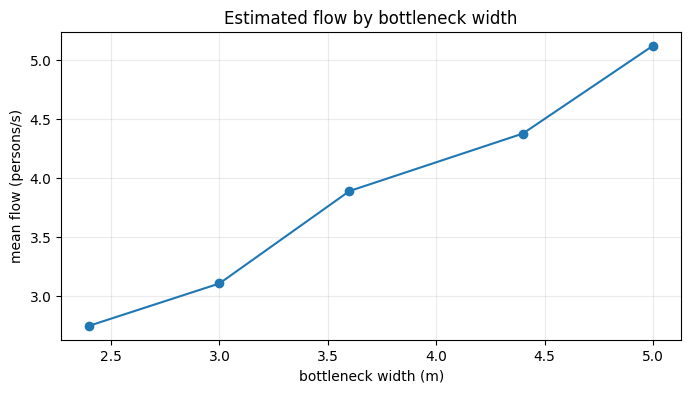

In [19]:
if not flow.empty:
    flow_summary = flow.groupby(["run", "bottleneck_width_m"], as_index=False).agg(
        mean_flow_p_per_s=("flow_p_per_s", "mean"),
        max_flow_p_per_s=("flow_p_per_s", "max"),
        line_y_m=("line_y_m", "first"),
    )
    display(flow_summary)

    plt.figure(figsize=(8, 4))
    plt.plot(flow_summary["bottleneck_width_m"], flow_summary["mean_flow_p_per_s"], marker="o")
    plt.xlabel("bottleneck width (m)")
    plt.ylabel("mean flow (persons/s)")
    plt.title("Estimated flow by bottleneck width")
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("No flow crossings detected. Inspect coordinate orientation and choose a better crossing line.")

### 16. Combine Calibration Summary

This table combines the first-pass SFM calibration observables:

- speed distribution,
- spacing distribution,
- bottleneck flow. (repulsion force? consider ditching...)

These are the values we can feed into or compare against an SFM estimator.

In [20]:
calibration_summary = summary.merge(spacing_summary, on=["run", "bottleneck_width_m"], how="left")
if "flow_summary" in globals() and not flow.empty:
    calibration_summary = calibration_summary.merge(flow_summary, on=["run", "bottleneck_width_m"], how="left")

calibration_summary

,run,bottleneck_width_m,n_pedestrians,n_frames,first_frame,last_frame,mean_speed_mps,median_speed_mps,std_speed_mps,p10_speed_mps,p90_speed_mps,duration_s,mean_nn_spacing_m,median_nn_spacing_m,p10_nn_spacing_m,mean_flow_p_per_s,max_flow_p_per_s,line_y_m
0,ao-240-400,2.4,352,1100,29,1128,0.458107,0.303475,0.385662,0.120656,1.108227,68.6875,0.428841,0.390236,0.282135,2.750000,7.0,-6.019550
1,ao-300-400,3.0,348,959,0,958,0.505935,0.356600,0.380541,0.142042,1.094345,59.8750,0.438525,0.403725,0.291127,3.107143,7.0,-6.022220
2,ao-360-400,3.6,350,808,14,821,0.586977,0.443724,0.393729,0.187395,1.171033,50.4375,0.447063,0.415884,0.302089,3.888889,8.0,-6.015665
3,ao-440-400,4.4,350,720,0,719,0.650029,0.549896,0.397155,0.218093,1.180541,44.9375,0.458363,0.433077,0.313795,4.375000,9.0,-6.002000
4,ao-500-400,5.0,348,605,1210,1814,0.741921,0.645050,0.427503,0.284062,1.305527,37.7500,0.454320,0.429277,0.312720,5.117647,8.0,-5.996040


In [21]:
out_path = OUTPUT_DIR / "hermes_bottleneck_calibration_summary.csv"
calibration_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: c:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\hermes_bottleneck\outputs\hermes_bottleneck_calibration_summary.csv


### 17. How These Metrics Map To The Social Force Model

| Observed quantity | How we compute it | SFM relevance |
|---|---|---|
| Speed distribution | Per-agent displacement over time | Estimates desired speed distribution and realised speed under congestion. |
| Direction | `atan2(dy, dx)` | Defines desired movement direction / goal direction. |
| Nearest-neighbour spacing | Minimum distance to another pedestrian per frame | Helps tune social repulsion and personal space. |
| Bottleneck flow | Number of pedestrians crossing a line per second | Validates bottleneck capacity and clogging behaviour. |
| Width sensitivity | Compare runs with different bottleneck widths | Tests whether the model reproduces flow-width relationship. |

This dataset is therefore useful for calibrating the movement physics of SFM before applying more complex emergency behaviours such as panic, group movement, blocked exits, or stadium-scale evacuation.

**i.e. these are the mechanics/values that need to be known to calibrate the parameters, and hence calculate a better calibrated SFM**

e.g. walking speeds of the agents are calibrated through the video, and hence for example, F = ma = m x (dv/dt), so without knowing the average/spread of velocities of agents, it's impossible to calibrate the SFM.

### 18. Calibration Parameters To Use For The Bottleneck Dataset

The Hermes bottleneck notebook does **not** need a pixel-to-metre scale because the trajectory files already provide coordinates in centimetres. Calibration therefore starts after this conversion:

```text
trajectory cm -> metres -> observed speed / spacing / flow -> SFM parameter fitting
```

The pasted parameter notes are useful, but for this dataset they should be narrowed to the parameters that can actually be supported by the observed bottleneck metrics.

| Config section | Parameter | Bottleneck calibration role | Recommendation for this notebook |
|---|---|---|---|
| `[scene]` | `agent_radius` | Physical body/personal-space size affects collisions and spacing | Tune carefully or hold fixed. Do not infer it directly from nearest-neighbour spacing because the trajectory point may be body centre/head position, not body edge. |
| `[scene]` | `max_speed_multiplier` | Caps unrealistic speeds relative to each agent's initial speed | Keep near `1.3` for normal crowd movement; only increase for emergency scenarios. |
| `[scene]` / `[desired_force]` | `tau` / `relaxation_time` | How quickly velocity adjusts toward desired velocity | Treat as one behavioural concept. In this codebase, check which simulator class reads which value before calibrating both. |
| `[desired_force]` | `goal_threshold` | Distance at which goal is considered reached | Use geometry/debug parameter. Do not optimise early unless agents fail to exit. |
| `[desired_force]` | `factor` | Weight of destination/goal force | Tune against speed and flow once bottleneck geometry is reproduced. |
| `[social_force]` | `factor`, `lambda_importance`, `gamma`, `n`, `n_prime` | Controls pedestrian-pedestrian avoidance and steering | Main candidates for fitting against nearest-neighbour spacing and flow. |
| `[obstacle_force]` | `factor`, `sigma`, `threshold` | Wall/barrier avoidance | Tune only after the bottleneck walls are represented in the simulation. |
| group forces | `group_coherence_force`, `group_repulsive_force`, `group_gaze_force` | Walking-together behaviour | Keep off or fixed for Hermes unless group labels are available. The bottleneck dataset is stronger for baseline pedestrian flow than group behaviour. |

For this notebook, the best first calibration targets are already computed: realised speed distribution, nearest-neighbour spacing, and flow per bottleneck width.

According to the original SFM paper done by Helbing et al., the total force F acting on a person at any given time t is:

$$F_{i} = F_{i}^{desire} + \sum_{j \neq i} F_{ij}^{social} + \sum_{w} F_{iw}^{obstacle}$$

i.e. the summation of Destination, Interaction and Obstacle Force.

**How are the parameters determined?**

Pedestrian motion is governed by a summation of "forces" representing physical and psychological motivations. Now, we should think about whether we want to use the information provided by this old paper to move forward, or calibrate our own SFM (which is what I recommend, especially if we're going to model on places like L10, SportsHub etc).

**1. Scene Parameters ([scene])**
- These define the physical constraints of the environment and the agents.

- `enable_group`: When set to true, the model accounts for group dynamics (e.g., friends or families walking together), adding specific forces for coherence and gaze
- `agent_radius`: The physical space an agent occupies. While your config uses 0.35m, Helbing's paper suggests a calibrated value of 0.27m for general studies, while it might be <= 0.2m for collision rate calculations (i.e. larger crowds)
- `max_speed_multiplier`: This prevents agents from reaching unrealistic speeds. The typical max velocity is ~2.5 m/s, although there are outliers (> 3 m/s)

**2. Desired Force ([desired_force])**
- Also known as the Destination Force, this represents the agent’s motivation to reach a specific goal

- `factor`: Weighting of the force in total calculation
- `goal_threshold`: Distance at which the agent considers the goal reached
- `relaxation_time`: Critical parameter. Measured in tau (τ), representing the time it takes for an agent to adjust their current velocity to their desired velocity. The paper assumes it to be 0.5s (adjust later?)

**3. Social Force ([social_force])**
- repulsive force between pedestrians to maintain personal space and avoid collisions

- `lambda_importance`: anisotropy of the force—how much more an agent is affected by people in front of them versus behind them
- `gamma`, `n`, `n_prime`: "speed interaction" and "angular interaction" of how pedestrians steer to avoid each other; from the Moussaid-Helbing heuristic model.


**4. Obstacle Force ([obstacle_force])**
- How agents steer away from walls, environmental barriers etc

- `sigma`: A parameter that modifies the smoothness of the force decay as the agent gets closer to an obstacle
- `threshold`: The distance (3.0m in your config) at which an agent begins to feel the "repulsion" from an obstacle (again, I think we have to configure our own. Need to understand & know how to do it)


**5. Group Forces**
- Manages internal dynamics of a walking group

- `group_coherence_force`: Keeps group members close to one another
- `group_repulsive_force`: Prevents group members from overlapping while maintaining a shared path
- `group_gaze_force`: Models the "field of view" (fov_phi = 90.0) within which agents interact with their group members

In [22]:
# Hermes-specific calibration parameter table.
# These are starting ranges for fitting; they are not final calibrated values.

calibration_parameter_plan = pd.DataFrame([
    {
        "config_section": "scene",
        "parameter": "agent_radius",
        "current_value": 0.35,
        "candidate_low": 0.20,
        "candidate_high": 0.35,
        "calibrate_now": False,
        "reason": "Body size affects collision/spacing, but nearest-neighbour spacing is not a direct body-radius measurement.",
    },
    {
        "config_section": "scene",
        "parameter": "max_speed_multiplier",
        "current_value": 1.30,
        "candidate_low": 1.10,
        "candidate_high": 1.50,
        "calibrate_now": True,
        "reason": "Caps unrealistic speeds while still allowing local acceleration through the bottleneck.",
    },
    {
        "config_section": "desired_force",
        "parameter": "relaxation_time",
        "current_value": 0.50,
        "candidate_low": 0.30,
        "candidate_high": 1.00,
        "calibrate_now": True,
        "reason": "Controls how quickly agents adapt velocity toward the desired direction.",
    },
    {
        "config_section": "desired_force",
        "parameter": "factor",
        "current_value": 1.00,
        "candidate_low": 0.50,
        "candidate_high": 2.00,
        "calibrate_now": True,
        "reason": "Affects speed recovery and throughput toward the exit.",
    },
    {
        "config_section": "social_force",
        "parameter": "factor",
        "current_value": 5.10,
        "candidate_low": 1.00,
        "candidate_high": 10.00,
        "calibrate_now": True,
        "reason": "Primary pedestrian-pedestrian repulsion strength; compare against spacing and flow.",
    },
    {
        "config_section": "social_force",
        "parameter": "lambda_importance",
        "current_value": 2.00,
        "candidate_low": 0.50,
        "candidate_high": 4.00,
        "calibrate_now": True,
        "reason": "Controls anisotropy / relative importance of velocity and position in avoidance.",
    },
    {
        "config_section": "social_force",
        "parameter": "gamma",
        "current_value": 0.35,
        "candidate_low": 0.10,
        "candidate_high": 0.80,
        "calibrate_now": True,
        "reason": "Moussaid-Helbing interaction scale; affects steering strength and spacing.",
    },
    {
        "config_section": "obstacle_force",
        "parameter": "factor",
        "current_value": 10.00,
        "candidate_low": 2.00,
        "candidate_high": 20.00,
        "calibrate_now": False,
        "reason": "Tune after bottleneck walls/barriers are encoded accurately.",
    },
    {
        "config_section": "group_forces",
        "parameter": "all group factors",
        "current_value": np.nan,
        "candidate_low": np.nan,
        "candidate_high": np.nan,
        "calibrate_now": False,
        "reason": "Hermes trajectories do not provide group labels; keep group dynamics disabled/fixed for baseline calibration.",
    },
])

display(calibration_parameter_plan)

,config_section,parameter,current_value,candidate_low,candidate_high,calibrate_now,reason
0,scene,agent_radius,0.35,0.2,0.35,False,"Body size affects collision/spacing, but neare..."
1,scene,max_speed_multiplier,1.30,1.1,1.50,True,Caps unrealistic speeds while still allowing l...
2,desired_force,relaxation_time,0.50,0.3,1.00,True,Controls how quickly agents adapt velocity tow...
3,desired_force,factor,1.00,0.5,2.00,True,Affects speed recovery and throughput toward t...
4,social_force,factor,5.10,1.0,10.00,True,Primary pedestrian-pedestrian repulsion streng...
5,social_force,lambda_importance,2.00,0.5,4.00,True,Controls anisotropy / relative importance of v...
6,social_force,gamma,0.35,0.1,0.80,True,Moussaid-Helbing interaction scale; affects st...
7,obstacle_force,factor,10.00,2.0,20.00,False,Tune after bottleneck walls/barriers are encod...
8,group_forces,all group factors,NaN,NaN,NaN,False,Hermes trajectories do not provide group label...


### 19. Empirical Targets From Hermes

The table below is the observed target set that the SFM simulation should try to reproduce. These are **real-world metric values**, not pixel measurements.

Important interpretation:

- Mean speed is realised speed under bottleneck congestion, so it is usually lower than free walking desired speed.
- The widest bottleneck run is the closest available proxy for less-constrained walking, but it is still not pure free flow.
- Flow should increase as bottleneck width increases; if the simulation does not reproduce this trend, the geometry or repulsive/obstacle forces are probably wrong.

In [23]:
target_columns = [
    "run",
    "bottleneck_width_m",
    "mean_speed_mps",
    "median_speed_mps",
    "std_speed_mps",
    "p90_speed_mps",
    "mean_nn_spacing_m",
    "median_nn_spacing_m",
    "mean_flow_p_per_s",
    "max_flow_p_per_s",
]

available_target_columns = [col for col in target_columns if col in calibration_summary.columns]
hermes_targets = calibration_summary[available_target_columns].copy()
display(hermes_targets)

if not hermes_targets.empty:
    widest_run = hermes_targets.sort_values("bottleneck_width_m").iloc[-1]
    print("Suggested initial desired speed proxy from widest bottleneck p90 speed:", round(widest_run["p90_speed_mps"], 3), "m/s")
    print("Observed mean speed range:", round(hermes_targets["mean_speed_mps"].min(), 3), "to", round(hermes_targets["mean_speed_mps"].max(), 3), "m/s")
    if "mean_flow_p_per_s" in hermes_targets:
        print("Observed mean flow range:", round(hermes_targets["mean_flow_p_per_s"].min(), 3), "to", round(hermes_targets["mean_flow_p_per_s"].max(), 3), "persons/s")

,run,bottleneck_width_m,mean_speed_mps,median_speed_mps,std_speed_mps,p90_speed_mps,mean_nn_spacing_m,median_nn_spacing_m,mean_flow_p_per_s,max_flow_p_per_s
0,ao-240-400,2.4,0.458107,0.303475,0.385662,1.108227,0.428841,0.390236,2.750000,7.0
1,ao-300-400,3.0,0.505935,0.356600,0.380541,1.094345,0.438525,0.403725,3.107143,7.0
2,ao-360-400,3.6,0.586977,0.443724,0.393729,1.171033,0.447063,0.415884,3.888889,8.0
3,ao-440-400,4.4,0.650029,0.549896,0.397155,1.180541,0.458363,0.433077,4.375000,9.0
4,ao-500-400,5.0,0.741921,0.645050,0.427503,1.305527,0.454320,0.429277,5.117647,8.0


Suggested initial desired speed proxy from widest bottleneck p90 speed: 1.306 m/s
Observed mean speed range: 0.458 to 0.742 m/s
Observed mean flow range: 2.75 to 5.118 persons/s


### 20. Calibration Objective Function

A Genetic Algorithm can be used later, but the required loss function is simple: run the SFM with a parameter set, compute the same metrics as the Hermes observations, then minimise weighted error.

For the first pass, compare aggregated metrics by bottleneck width rather than full path-by-path MSE. Full trajectory MSE requires matching each simulated agent to a real pedestrian, which is harder and may not be necessary for baseline calibration.

In [24]:
def normalised_metric_mse(simulated, observed, metric_cols, key_cols=("run", "bottleneck_width_m"), weights=None):
    """Compare simulated and observed summary metrics.

    Both inputs should contain one row per run / bottleneck width and the same metric columns.
    The error is normalised by the observed metric scale so that flow does not dominate speed.
    """
    weights = weights or {}
    merged = observed.merge(simulated, on=list(key_cols), suffixes=("_obs", "_sim"))
    if merged.empty:
        return np.inf, pd.DataFrame()

    rows = []
    total = 0.0
    total_weight = 0.0

    for metric in metric_cols:
        obs_col = f"{metric}_obs"
        sim_col = f"{metric}_sim"
        if obs_col not in merged.columns or sim_col not in merged.columns:
            continue

        obs = merged[obs_col].astype(float)
        sim = merged[sim_col].astype(float)
        scale = max(float(obs.abs().median()), 1e-6)
        squared_error = ((sim - obs) / scale) ** 2
        metric_mse = float(squared_error.mean())
        weight = float(weights.get(metric, 1.0))

        rows.append({"metric": metric, "normalised_mse": metric_mse, "weight": weight})
        total += weight * metric_mse
        total_weight += weight

    loss = total / total_weight if total_weight else np.inf
    return loss, pd.DataFrame(rows)


metric_cols = [
    "mean_speed_mps",
    "median_speed_mps",
    "mean_nn_spacing_m",
    "mean_flow_p_per_s",
]

metric_weights = {
    "mean_speed_mps": 1.0,
    "median_speed_mps": 1.0,
    "mean_nn_spacing_m": 1.5,
    "mean_flow_p_per_s": 2.0,
}

print("Objective ready. Next required function: simulate_sfm_bottleneck_with_params(params).")

Objective ready. Next required function: simulate_sfm_bottleneck_with_params(params).


### 21. Parameter Search Skeleton

This is the place where a GA can be plugged in later. For now, the cell creates parameter samples and defines the expected interface.

Expected simulator function:

```python
simulate_sfm_bottleneck_with_params(params) -> pd.DataFrame
```

The returned dataframe should contain the same metric columns as `hermes_targets`, one row per bottleneck width.

In [25]:
def sample_parameter_sets(parameter_plan, n=20, seed=42):
    rng = np.random.default_rng(seed)
    tunable = parameter_plan[
        (parameter_plan["calibrate_now"] == True)
        & parameter_plan["candidate_low"].notna()
        & parameter_plan["candidate_high"].notna()
    ].copy()

    samples = []
    for sample_id in range(n):
        row = {"sample_id": sample_id}
        for _, param in tunable.iterrows():
            name = f"{param['config_section']}.{param['parameter']}"
            row[name] = rng.uniform(param["candidate_low"], param["candidate_high"])
        samples.append(row)
    return pd.DataFrame(samples)


parameter_samples = sample_parameter_sets(calibration_parameter_plan, n=10, seed=7)
display(parameter_samples)


def simulate_sfm_bottleneck_with_params(params):
    """TODO: replace this stub with the actual PySocialForce bottleneck simulation.

    The simulation should:
    1. create bottleneck geometry for each Hermes width,
    2. initialise agents using comparable starting positions / desired goals,
    3. run the simulator with the candidate config values,
    4. compute speed, spacing, and flow using the same functions above,
    5. return one summary row per bottleneck width.
    """
    return pd.DataFrame()


def evaluate_parameter_samples(parameter_samples, observed_targets, metric_cols=metric_cols, metric_weights=metric_weights):
    results = []
    for _, sample in parameter_samples.iterrows():
        params = sample.drop(labels=["sample_id"]).to_dict()
        simulated = simulate_sfm_bottleneck_with_params(params)
        if simulated.empty:
            results.append({"sample_id": sample["sample_id"], "loss": np.nan, "status": "simulation stub not implemented"})
            continue
        loss, _ = normalised_metric_mse(simulated, observed_targets, metric_cols, weights=metric_weights)
        results.append({"sample_id": sample["sample_id"], "loss": loss, "status": "evaluated"})
    return pd.DataFrame(results)


sample_results = evaluate_parameter_samples(parameter_samples, hermes_targets)
display(sample_results)

,sample_id,scene.max_speed_multiplier,desired_force.relaxation_time,desired_force.factor,social_force.factor,social_force.lambda_importance,social_force.gamma
0,0,1.350038,0.928050,1.663529,3.026865,1.550582,0.711487
1,1,1.102106,0.874860,1.695604,5.211415,1.560613,0.294898
2,2,1.201948,0.611553,1.256822,5.981476,3.984251,0.654863
3,3,1.348872,0.992272,0.822963,2.441908,2.643889,0.130759
4,4,1.114272,0.660422,1.199309,9.254510,2.702292,0.459882
5,5,1.298749,0.473260,0.517691,2.731619,2.922112,0.240425
6,6,1.247815,0.302614,1.745072,2.390150,1.436598,0.716233
7,7,1.303916,0.893005,1.459576,7.675939,0.820235,0.478801
8,8,1.303109,0.909938,1.041896,6.383657,0.707381,0.371342
9,9,1.229215,0.405140,1.724507,4.415016,3.925618,0.512994


,sample_id,loss,status
0,0.0,NaN,simulation stub not implemented
1,1.0,NaN,simulation stub not implemented
2,2.0,NaN,simulation stub not implemented
3,3.0,NaN,simulation stub not implemented
4,4.0,NaN,simulation stub not implemented
5,5.0,NaN,simulation stub not implemented
6,6.0,NaN,simulation stub not implemented
7,7.0,NaN,simulation stub not implemented
8,8.0,NaN,simulation stub not implemented
9,9.0,NaN,simulation stub not implemented


### 22. Updated Next Steps

Recommended next steps for **this** bottleneck notebook:

1. Keep the centimetre-to-metre trajectory conversion as the calibrated scale. There is no pixel-to-metre ratio to estimate for Hermes.
2. Verify the flow line direction using trajectory plots and video preview.
3. Replace the rough median-final-`y` crossing line with the actual bottleneck exit line from experiment geometry.
4. Build a minimal PySocialForce bottleneck simulation for the five widths: `2.4`, `3.0`, `3.6`, `4.4`, and `5.0` m.
5. Keep group forces fixed/off for the first baseline because the Hermes files do not provide group labels.
6. Fit only a small parameter set first: `desired_force.factor`, `desired_force.relaxation_time`, `scene.max_speed_multiplier`, `social_force.factor`, `social_force.lambda_importance`, and `social_force.gamma`.
7. Compare simulated vs observed `mean_speed_mps`, `median_speed_mps`, `mean_nn_spacing_m`, and `mean_flow_p_per_s` using the objective function above.
8. After the simulator returns comparable metrics, replace the random sampling scaffold with a Genetic Algorithm.

Suggested report wording:

> The Hermes bottleneck dataset provides real-world trajectories in centimetres, so pixel-to-metre calibration is unnecessary. I convert centimetres to metres, extract observed speed, spacing, and flow by bottleneck width, then use those values as calibration targets for the Social Force Model. The first calibration stage should fit baseline desired-force and pedestrian-repulsion parameters while keeping group behaviour fixed, because group labels are not available in this dataset.